# QuanAllo — Quick Start

Welcome to **QuanAllo**, a Python package for predicting allosteric (distal regulatory) pockets in proteins using quantum walker algorithms.

In this 5-minute tutorial you will:

1. Build a residue contact graph from an apo PDB file.
2. Run the default `DQAWLifetime` predictor.
3. Inspect the top-5 predicted residues.
4. (Optional) Compare to a holo structure to score the prediction.

> **About the example data.** We use **KRAS G12C**, the GTPase from the Cleveland Clinic Quantum + AI Challenge 2026. The apo structure is PDB **4OBE** (nucleotide-binding pocket marked by GDP), and the holo structure is **6OIM** (drug-bound form, with Sotorasib at the allosteric pocket — PDB ligand code **MOV**).

## 1. Install

In [1]:
# Latest release from PyPI:
# !pip install quanallo

# Or, for development:
# !pip install -e ../   # from the repo root

## 2. Build a protein graph from a PDB file

`ProteinGraph.from_pdb()` does end-to-end parsing: it reads the PDB, extracts Cα coordinates, builds the contact graph (8 Å cutoff, Gaussian-weighted), computes per-residue SASA + surface flag, and optionally auto-detects the active site by ligand proximity.

```python
from quanallo import ProteinGraph

apo = ProteinGraph.from_pdb(
    pdb_path="path/to/4OBE.pdb",
    auto_active_site_ligand="GDP",   # GDP marks the nucleotide pocket = active site
    active_site_radius=4.5,
    name="KRAS_APO",
)
print(apo)
# → ProteinGraph(name='KRAS_APO', N=169, |active|=22, no GT)
```

For this tutorial — since you may not have the PDB file on hand — we instead load the **preprocessed** KRAS graph data (CSV + NPY files produced by `stage1_consolidated.py`):

In [2]:
# Alternative: load preprocessed data
import pandas as pd, numpy as np
from quanallo import ProteinGraph

def _build_weighted(edges_df, N):
    A = np.zeros((N, N))
    for _, r in edges_df.iterrows():
        i, j = int(r['i']), int(r['j']); w = float(r['weight'])
        A[i, j] = w; A[j, i] = w
    return A

DATA = "input_KRAS"  # adjust to your path

apo_nodes = pd.read_csv(f"{DATA}/apo_nodes.csv")
apo_edges = pd.read_csv(f"{DATA}/apo_edges.csv")
apo_A_bin = np.load(f"{DATA}/apo_adjacency.npy").astype(float)
apo_A_w   = _build_weighted(apo_edges, len(apo_nodes))

key = apo_nodes.set_index(['chain','resnum'])['idx']
def _to_idx(df):
    return np.array([int(key.loc[(r.chain, int(r.resnum))]) for _, r in df.iterrows()
                     if (r.chain, int(r.resnum)) in key.index])

apo = ProteinGraph(
    nodes=apo_nodes,
    adjacency_binary=apo_A_bin,
    adjacency_weighted=apo_A_w,
    active_idx=_to_idx(pd.read_csv(f"{DATA}/apo_active_site.csv")),
    ground_truth_idx=_to_idx(pd.read_csv(f"{DATA}/holo_ground_truth.csv")),
    name="KRAS_G12C_APO",
)
print(apo)

ProteinGraph(name='KRAS_G12C_APO', N=169, |active|=22, |GT|=21)


## 3. Predict allosteric residues with a single line

The `AllostericPredictor` is your one-stop shop. Default settings already use the best single method we found in benchmarks (`dqaw_lifetime` — see notebook #2 for the comparison).

In [3]:
from quanallo import AllostericPredictor

predictor = AllostericPredictor(method="dqaw_lifetime", top_k=5)
result = predictor.predict(apo)

print(result)
print()
print("Top-5 residues:")
for rank, hit in enumerate(result.top_residues, start=1):
    print(f"  {rank}. {hit['chain']}{hit['resnum']:>3} {hit['resname']}")

PredictionResult(method='dqaw_lifetime', top-5 = A95,A67,A91,A62,A101, weighted_top5=3.500)

Top-5 residues:
  1. A 95 HIS
  2. A 67 MET
  3. A 91 GLU
  4. A 62 GLU
  5. A101 LYS


## 4. (Optional) Compare against a HOLO ground truth

If a holo structure with a known allosteric drug is available, we can use it to *score* the prediction. The HOLO ligand (Sotorasib, residue `MOV`) defines the ground-truth pocket; we measure how close our top-5 predictions are.

In [5]:
# Build the holo graph with ground truth
holo_nodes = pd.read_csv(f"{DATA}/holo_nodes.csv")
holo_edges = pd.read_csv(f"{DATA}/holo_edges.csv")
holo_A_bin = np.load(f"{DATA}/holo_adjacency.npy").astype(float)
holo_A_w   = _build_weighted(holo_edges, len(holo_nodes))
key_h = holo_nodes.set_index(['chain','resnum'])['idx']
def _to_idx_h(df):
    return np.array([int(key_h.loc[(r.chain, int(r.resnum))]) for _, r in df.iterrows()
                     if (r.chain, int(r.resnum)) in key_h.index])

holo = ProteinGraph(
    nodes=holo_nodes, adjacency_binary=holo_A_bin, adjacency_weighted=holo_A_w,
    active_idx=_to_idx_h(pd.read_csv(f"{DATA}/apo_active_site.csv")),
    ground_truth_idx=_to_idx_h(pd.read_csv(f"{DATA}/holo_ground_truth.csv")),
    name="KRAS_G12C_HOLO",
)

# Run the same predictor on HOLO graph
result = predictor.predict(holo)
print(result)
print()
print(f"Weighted top-5 (fuzzy GT credit, max=5.0): {result.weighted_top5:.3f}")
print(f"Precision@5 by hop tolerance:")
for k, p in result.precision_at_k.items():
    print(f"  k={k} hops:  {p:.0%}")

PredictionResult(method='dqaw_lifetime', top-5 = A70,A67,A103,A73,A38, weighted_top5=3.000)

Weighted top-5 (fuzzy GT credit, max=5.0): 3.000
Precision@5 by hop tolerance:
  k=0 hops:  20%
  k=1 hops:  100%
  k=2 hops:  100%
  k=3 hops:  100%
  k=4 hops:  100%
  k=5 hops:  100%


## 5. Inspect the hit list as a DataFrame

Every `PredictionResult` knows how to convert itself into a tidy table:

In [6]:
df = result.to_dataframe()
print(df)

   idx chain  resnum resname  hop_to_gt  credit
0   70     A      70     GLN          1     0.5
1   67     A      67     MET          1     0.5
2  103     A     103     VAL          0     1.0
3   73     A      73     ARG          1     0.5
4   38     A      38     ASP          1     0.5


## 6. Visualize on the 3D structure

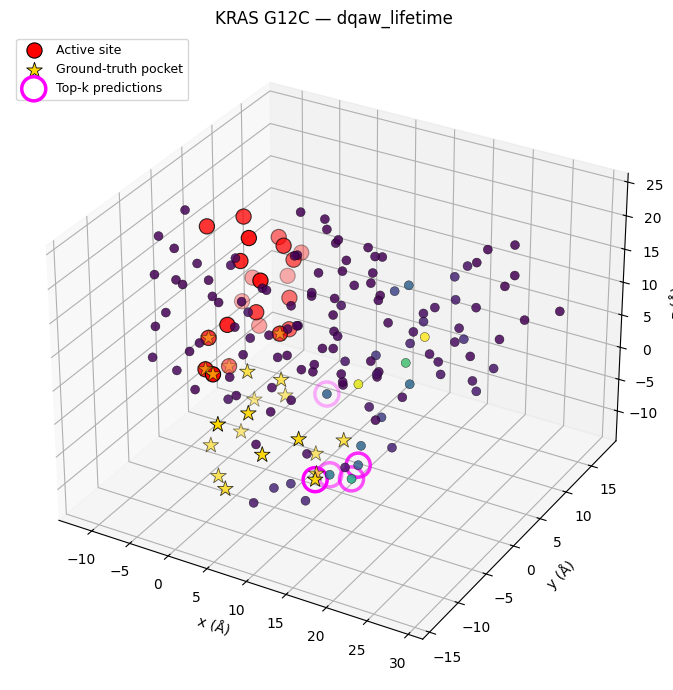

In [7]:
import matplotlib.pyplot as plt
from quanallo.visualization import plot_scores_3d

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
plot_scores_3d(
    holo, result.scores, top_indices=result.top_indices,
    title=f"KRAS G12C — {result.method_used}", ax=ax,
)
plt.tight_layout()
plt.show()

## 7. Next steps

You have just built and scored an allosteric pocket predictor in 20 lines of code. Next:

- **Notebook 02 — methods deep dive**: compare all 9 prediction methods on KRAS.
- **Notebook 03 — QuanAnt machines**: ant colonies and APO→HOLO transfer learning.

For a **one-liner** that does PDB → prediction in a single call:

```python
predictor = AllostericPredictor(method="dqaw_lifetime")
result = predictor.predict_from_pdb(
    apo_pdb="4OBE.pdb",
    holo_pdb="6OIM.pdb",            # optional, for scoring
    auto_active_site_ligand="GDP",
    holo_drug_name="MOV",            # for ground-truth detection
    top_k=5,
)
print(result)
```